# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sorgerator/flyrank-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

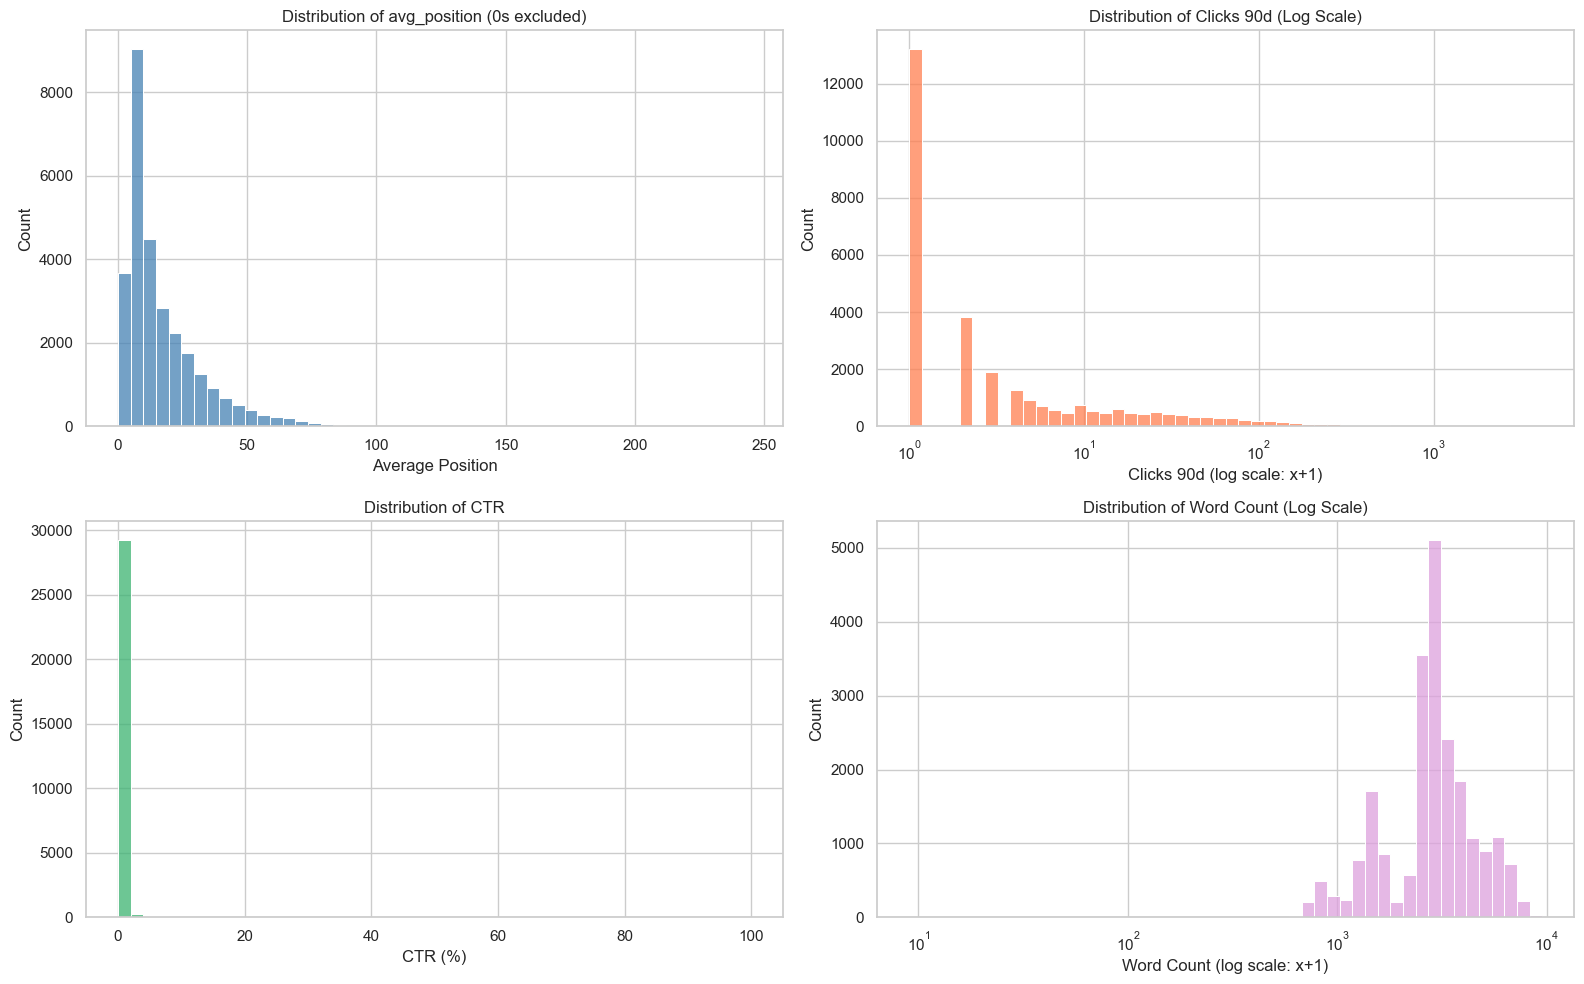

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

valid_positions = df[df['avg_position'] > 0]['avg_position']
sns.histplot(valid_positions.dropna(), bins=50, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribution of avg_position (0s excluded)')
axes[0, 0].set_xlabel('Average Position')
axes[0, 0].set_ylabel('Count')

sns.histplot(df['clicks_90d'] + 1, bins=50, log_scale=True, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Distribution of Clicks 90d (Log Scale)')
axes[0, 1].set_xlabel('Clicks 90d (log scale: x+1)')
axes[0, 1].set_ylabel('Count')

sns.histplot(df['ctr'].dropna(), bins=50, ax=axes[1, 0], color='mediumseagreen')
axes[1, 0].set_title('Distribution of CTR')
axes[1, 0].set_xlabel('CTR (%)')
axes[1, 0].set_ylabel('Count')

sns.histplot(df['word_count'].dropna() + 1, bins=50, log_scale=True, ax=axes[1, 1], color='plum')
axes[1, 1].set_title('Distribution of Word Count (Log Scale)')
axes[1, 1].set_xlabel('Word Count (log scale: x+1)')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

The distributions reveal extreme positive skew (heavy right tails) for raw volume metrics like clicks_90d and word_count, requiring logarithmic scaling to visualize properly. Conversely, percentage metrics like ctr and filtered metrics like avg_position show distinct, non-heavy-tailed distributions, underscoring the need to handle missing values (NaNs) and false zeros before modeling.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

C:\Users\User\AppData\Local\Temp\ipykernel_28096\2176426789.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ctr_test, x='trend_direction', y='ctr', palette='Set2')


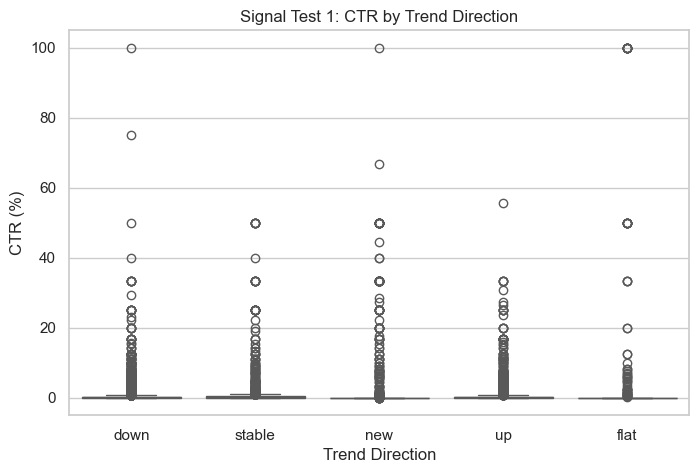

Median CTR by Trend:
trend_direction
down      0.08
flat      0.00
new       0.00
stable    0.17
up        0.09
Name: ctr, dtype: float64


In [13]:
# --- Signal Test 1: CTR ---
# Hypothesis: Declining content has lower click-through rates.

df_ctr_test = df[['ctr', 'trend_direction']].dropna()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_ctr_test, x='trend_direction', y='ctr', palette='Set2')
plt.title('Signal Test 1: CTR by Trend Direction')
plt.ylabel('CTR (%)')
plt.xlabel('Trend Direction')
plt.show()

print("Median CTR by Trend:")
print(df_ctr_test.groupby('trend_direction')['ctr'].median())

Verdict: MIXED. Declining content has a median CTR of 0.08%, which is slightly lower than stable (0.17%) but almost identical to trending up (0.09%). There is a directional link, but it is weak.

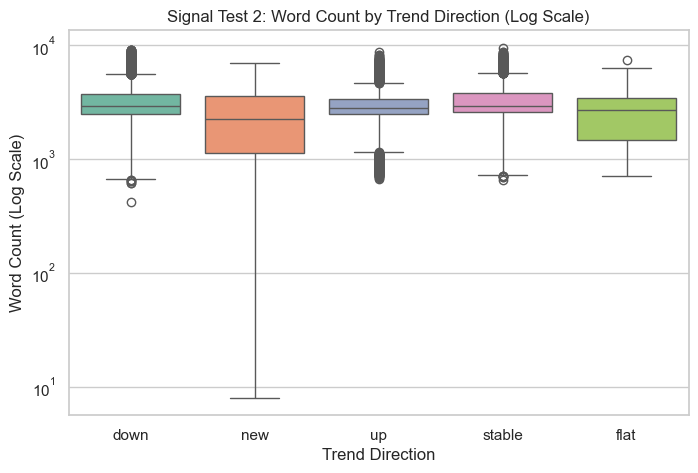

Median Word Count by Trend:
trend_direction
down      2909.0
flat      2698.5
new       2239.0
stable    2912.5
up        2847.5
Name: word_count, dtype: float64


In [14]:
# --- Signal Test 2: Word Count ---
# Hypothesis: Declining content has lower word counts (thinner content).

df_wc_test = df[['word_count', 'trend_direction']].dropna()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_wc_test, x='trend_direction', y='word_count', hue='trend_direction', palette='Set2', legend=False)
plt.yscale('log')
plt.title('Signal Test 2: Word Count by Trend Direction (Log Scale)')
plt.ylabel('Word Count (Log Scale)')
plt.xlabel('Trend Direction')
plt.show()

print("Median Word Count by Trend:")
print(df_wc_test.groupby('trend_direction')['word_count'].median())

Verdict: FALSE. Declining content actually has a higher median word count (2909.0) than content trending up (2847.5), strictly refuting the assumption that "thin" content is more likely to decline.

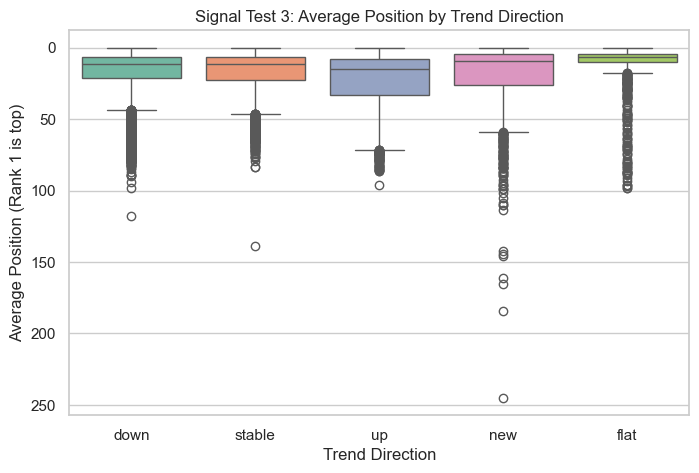

Median Average Position by Trend:
trend_direction
down      11.3
flat       6.8
new        9.7
stable    11.4
up        15.3
Name: avg_position, dtype: float64


In [15]:
# --- Signal Test 3: Average Position ---
# Hypothesis: Declining content has worse (higher numeric) average search positions.

df_pos_test = df[df['avg_position'] > 0][['avg_position', 'trend_direction']].dropna()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_pos_test, x='trend_direction', y='avg_position', hue='trend_direction', palette='Set2', legend=False)
plt.title('Signal Test 3: Average Position by Trend Direction')
plt.ylabel('Average Position (Rank 1 is top)')
plt.xlabel('Trend Direction')
plt.gca().invert_yaxis() 
plt.show()

print("Median Average Position by Trend:")
print(df_pos_test.groupby('trend_direction')['avg_position'].median())

Verdict: OPPOSITE. Content trending down has a better median search position (11.3) than content trending up (15.3), contradicting the assumption that lower-ranking content declines faster.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

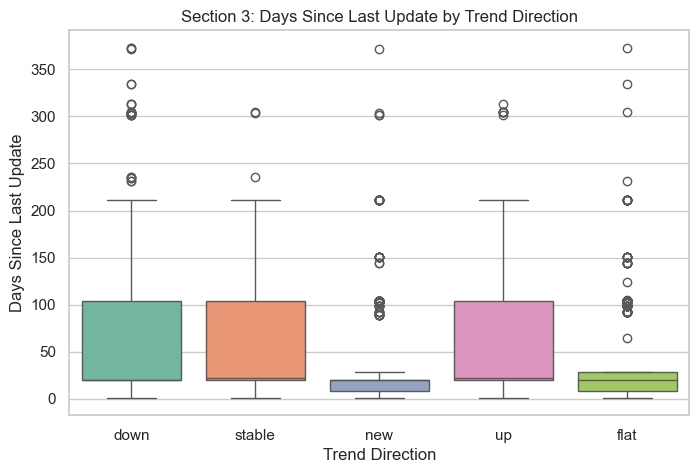

Median Days Since Last Update by Trend:
trend_direction
down      20.0
flat      20.0
new       20.0
stable    22.0
up        22.0
Name: days_since_last_update, dtype: float64


In [16]:
# --- Section 3: The Flag-Linked Test ---
# Flag tested: "Stale Content" 
# Hypothesis: Declining content hasn't been updated recently (higher days_since_last_update).

df_freshness_test = df[['days_since_last_update', 'trend_direction']].dropna()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_freshness_test, 
    x='trend_direction', 
    y='days_since_last_update', 
    hue='trend_direction', 
    palette='Set2', 
    legend=False
)
plt.title('Section 3: Days Since Last Update by Trend Direction')
plt.ylabel('Days Since Last Update')
plt.xlabel('Trend Direction')
plt.show()

print("Median Days Since Last Update by Trend:")
print(df_freshness_test.groupby('trend_direction')['days_since_last_update'].median())

Verdict: FALSE. The median days since the last update for declining content is 20 days, which is virtually identical to content trending up (22 days). The data does not support the assumption that older, un-refreshed content is more prone to decline.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

Content teams should not rely blindly on industry-standard heuristics—like word count, search position, or freshness—to predict performance drops, as this dataset shows no directional link between these metrics and a downward trend. Instead, teams must audit their specific data to find empirically supported signals (like CTR or engagement) before setting automated flags, ensuring their maintenance efforts are driven by measured reality rather than assumptions.

## Self-check

Before you submit, confirm each line honestly:

- [ **X** ] Every section above is filled — markdown thinking AND the code that backs it
- [ **X** ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ **X** ] No client names, URLs, or private queries anywhere
- [ **X** ] My claims use careful words: observed, measured, directional, decision-support
- [ **X** ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.